In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
import torch
import clip
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm
from PIL import Image
import seaborn as sns
import math

In [3]:
root = "/home/amirhossein.hajimohammadrezaie/ECOR_extended"
dataset_name = 'cifar100'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, preprocess = clip.load("ViT-B/32", device=device)
preprocess = transforms.Compose([transforms.Resize((224, 224), transforms.InterpolationMode.BICUBIC, antialias=True)] + preprocess.transforms)
model.eval()
model = model.to(torch.float32)
batch_size = 128

for param in model.parameters():
    param.requires_grad = False

In [4]:
def preprocess_cat_rat(json_path):
        
        data = pd.read_json(json_path)  
        unique_cats = data['category'].apply(lambda cat: cat.lower().strip()).unique()
        cat2id = dict(zip(unique_cats, range(len(unique_cats))))
                
        return cat2id

cat2id = preprocess_cat_rat(f'{root}/Datasets/{dataset_name}_dr/stats_train.json')
cat_names = np.array(list(cat2id.keys()))

In [5]:
class ECORDataset(Dataset):
    def __init__(self, preprocess, json_path):
        super().__init__()

        self.preprocess = preprocess
        self.data = pd.read_json(json_path)    
        self.cat2id = None
        self.cat_names = None
        self.preprocess_cat()
        
    def preprocess_cat(self):
            unique_cats = self.data['category'].apply(lambda cat: cat.lower().strip()).unique()
            self.cat2id = dict(zip(unique_cats, range(len(unique_cats))))
            self.cat_names = np.array(list(cat2id.keys()))

    def __getitem__(self, index):
        image = self.preprocess(Image.open(self.data.iloc[index]['image']))
        category = self.cat2id[self.data.iloc[index]['category']]
        return image, category

    def __len__(self):
        return len(self.data)

In [6]:
dataset = ECORDataset(preprocess, f'{root}/Datasets/{dataset_name}_dr/stats_train.json')
dataLoader = DataLoader(dataset, batch_size, shuffle=False)

In [ ]:
@torch.no_grad()
def compute_cats_embedding(model, cat2id):
    cats_embed = []
    block_size = 50
    blocks_num = np.ceil(len(cat2id)/block_size).astype(int)
    
    for i in tqdm(range(blocks_num), total=blocks_num):
        cats_tokens_temp = clip.tokenize(pd.Series(list(cat2id.keys())[i*block_size:min((i+1)*block_size, len(cat2id))]).apply(lambda cat: f'a photo of a ' + cat)).to(device)
        cats_embeds_temp = F.normalize(model.encode_text(cats_tokens_temp), dim=-1)
        cats_embed.append(cats_embeds_temp)
    
    cats_embed = torch.cat(cats_embed, dim=0).cpu()
    return cats_embed

all_cats_embed = compute_cats_embedding(model, dataset.cat2id)

100%|██████████| 2/2 [00:00<00:00,  4.25it/s]


## Start

In [8]:
with torch.no_grad():
    all_imgs_embed = []
    corresponding_cats = []

    for imgs, cats in tqdm(dataLoader, total=len(dataLoader)):
        
        imgs = imgs.to(device)            
        imgs_embed = F.normalize(model.encode_image(imgs))
    
        for i, cat in enumerate(cats):
            all_imgs_embed.append(imgs_embed[i].cpu())
            corresponding_cats.append(cat.item())            
            

    all_imgs_embed = torch.stack(all_imgs_embed, dim=0)
    corresponding_cats = torch.tensor(corresponding_cats)

100%|██████████| 88/88 [00:45<00:00,  1.93it/s]


In [16]:
def get_entropy(l):
    _, count = np.unique(l, return_counts=True)
    if len(count) == 1:
        return 0
    return -np.sum(count/len(l) * np.log2(count/len(l)))


with torch.no_grad():
    scores = all_cats_embed @ all_imgs_embed.t()
    scores_neg = (-all_cats_embed) @ all_imgs_embed.t()
    _, idxs = torch.topk(scores, k=5, dim=-1) # 98 x 5
    _, idxs_neg = torch.topk(scores_neg, k=5, dim=-1) # 98 x 5
    preds = corresponding_cats.expand((idxs.shape[0], -1))[torch.arange(idxs.shape[0]).unsqueeze(1), idxs].numpy()
    
    results = []
    for pred in preds:
        results.append(get_entropy(pred))

In [26]:
@torch.no_grad()
def compute_aff_neg_cats_embedding(model, cat2id):
    aff_cats_embed = []
    neg_cats_embed = []
    block_size = 50
    blocks_num = np.ceil(len(cat2id)/block_size).astype(int)
    
    for i in tqdm(range(blocks_num), total=blocks_num):
        neg_cats_tokens_temp = clip.tokenize(pd.Series(list(cat2id.keys())[i*block_size:min((i+1)*block_size, len(cat2id))]).apply(lambda cat: 'A photo of a ' + cat)).to(device)
        neg_cats_embeds_temp = F.normalize(model.encode_text(neg_cats_tokens_temp), dim=-1)
        neg_cats_embed.append(neg_cats_embeds_temp)

        aff_cats_tokens_temp = clip.tokenize(pd.Series(list(cat2id.keys())[i*block_size:min((i+1)*block_size, len(cat2id))]).apply(lambda cat: 'This is a photo')).to(device)
        aff_cats_embeds_temp = F.normalize(model.encode_text(aff_cats_tokens_temp), dim=-1)
        aff_cats_embed.append(aff_cats_embeds_temp)

    
    neg_cats_embed = torch.cat(neg_cats_embed, dim=0).cpu()
    aff_cats_embed = torch.cat(aff_cats_embed, dim=0).cpu()

    return aff_cats_embed, neg_cats_embed

all_aff_cats_embed, all_neg_cats_embed = compute_aff_neg_cats_embedding(model, dataset.cat2id)

100%|██████████| 2/2 [00:00<00:00, 29.10it/s]


In [94]:
thresholds = [0.99, 0.9, 0.7]
results_new = {}
idxs_new = {}
with torch.no_grad():
    for threshold in thresholds:
        alpha = math.acos(threshold) 
        a_T_n = torch.sum(all_aff_cats_embed * all_neg_cats_embed, dim=-1) # cos(theta) : B,
        theta = torch.acos(a_T_n) # Theta : B,
        mask = theta < 2 * alpha

        delta = alpha + theta/2.
        all_new_cats_embed = torch.cos(delta)[:, None] * all_neg_cats_embed + (torch.sin(delta)/torch.sin(theta))[:, None] * (all_aff_cats_embed - a_T_n[:, None]*all_neg_cats_embed)

        scores_new = all_new_cats_embed @ all_imgs_embed.t()
        _, idxs_new[threshold] = torch.topk(scores_new, k=5, dim=-1) # 98 x 5
        preds = corresponding_cats.expand((idxs_new[threshold].shape[0], -1))[torch.arange(idxs_new[threshold].shape[0]).unsqueeze(1), idxs_new[threshold]].numpy()
        
        results_new[threshold] = []
        for pred in preds:
            results_new[threshold].append(get_entropy(pred))

    

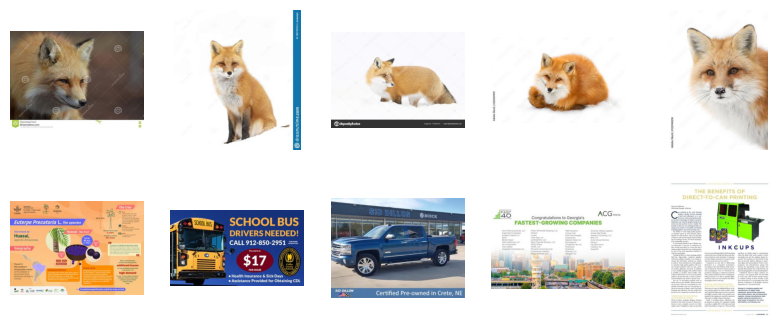

In [20]:
cat = 'fox'
cat_id = cat2id[cat]

plt.figure(figsize=(10, 4))


for i, idx in enumerate(idxs[cat_id]):
    plt.subplot(2, 5, i+1)
    plt.imshow(np.array(Image.open(dataset.data.iloc[idx.item()]['image'])))
    plt.axis('off')


for i, idx in enumerate(idxs_neg[cat_id], start=5):
    plt.subplot(2, 5, i+1)
    plt.imshow(np.array(Image.open(dataset.data.iloc[idx.item()]['image'])))
    plt.axis('off')

plt.show()

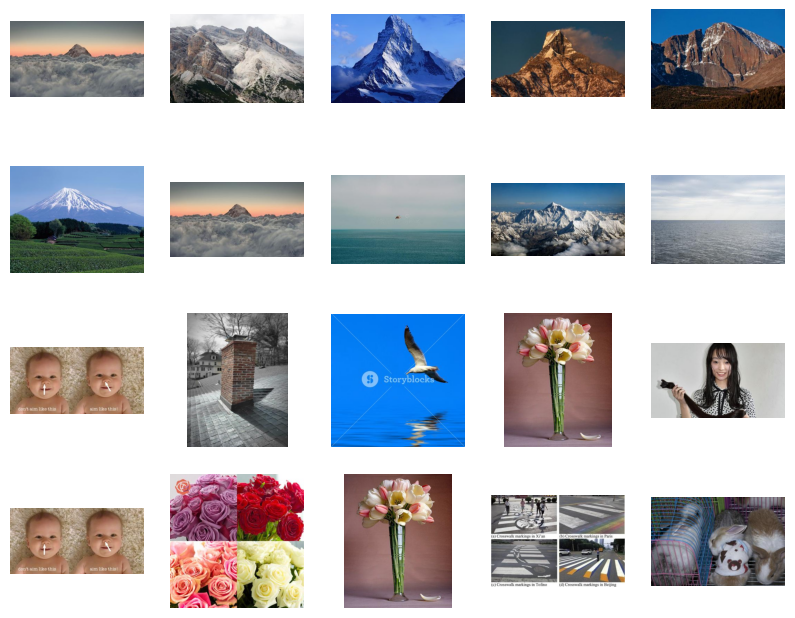

In [98]:
cat = 'mountain'
cat_id = cat2id[cat]

plt.figure(figsize=(10, 8))

for i, idx in enumerate(idxs[cat_id]):
    plt.subplot(4, 5, i+1)
    plt.imshow(np.array(Image.open(dataset.data.iloc[idx.item()]['image'])))
    plt.axis('off')


for i, idx in enumerate(idxs_new[0.99][cat_id], start=5):
    plt.subplot(4, 5, i+1)
    plt.imshow(np.array(Image.open(dataset.data.iloc[idx.item()]['image'])))
    plt.axis('off')

for i, idx in enumerate(idxs_new[0.9][cat_id], start=10):
    plt.subplot(4, 5, i+1)
    plt.imshow(np.array(Image.open(dataset.data.iloc[idx.item()]['image'])))
    plt.axis('off')

for i, idx in enumerate(idxs_new[0.7][cat_id], start=15):
    plt.subplot(4, 5, i+1)
    plt.imshow(np.array(Image.open(dataset.data.iloc[idx.item()]['image'])))
    plt.axis('off')

plt.show()

In [39]:
cat2id

{'ray': 0,
 'pear': 1,
 'lamp': 2,
 'spider': 3,
 'raccoon': 4,
 'shark': 5,
 'chimpanzee': 6,
 'telephone': 7,
 'pickup truck': 8,
 'rocket': 9,
 'streetcar': 10,
 'seal': 11,
 'cockroach': 12,
 'lizard': 13,
 'mountain': 14,
 'oak tree': 15,
 'lawn mower': 16,
 'worm': 17,
 'bowl': 18,
 'flatfish': 19,
 'aquarium fish': 20,
 'porcupine': 21,
 'possum': 22,
 'bus': 23,
 'willow tree': 24,
 'woman': 25,
 'man': 26,
 'house': 27,
 'maple tree': 28,
 'clock': 29,
 'dolphin': 30,
 'keyboard': 31,
 'cup': 32,
 'crocodile': 33,
 'bed': 34,
 'girl': 35,
 'chair': 36,
 'turtle': 37,
 'squirrel': 38,
 'pine tree': 39,
 'snake': 40,
 'beetle': 41,
 'tulip': 42,
 'bridge': 43,
 'beaver': 44,
 'poppy': 45,
 'bear': 46,
 'apple': 47,
 'sea': 48,
 'shrew': 49,
 'dinosaur': 50,
 'mushroom': 51,
 'crab': 52,
 'tractor': 53,
 'lobster': 54,
 'plate': 55,
 'rabbit': 56,
 'train': 57,
 'plain': 58,
 'sweet pepper': 59,
 'table': 60,
 'tank': 61,
 'hamster': 62,
 'can': 63,
 'palm tree': 64,
 'forest': 6

In [35]:
idxs.shape

torch.Size([98, 5])

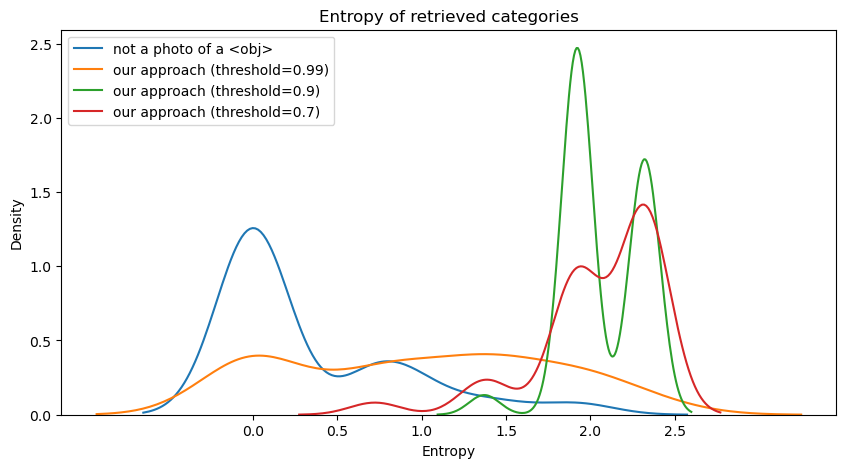

In [99]:
plt.figure(figsize=(10, 5))
sns.kdeplot(results)
sns.kdeplot(results_new[0.99])
sns.kdeplot(results_new[0.9])
sns.kdeplot(results_new[0.7])

plt.title("Entropy of retrieved categories")
plt.xlabel("Entropy")
plt.ylabel("Density")
plt.legend(['not a photo of a <obj>', 'our approach (threshold=0.99)', 'our approach (threshold=0.9)', 'our approach (threshold=0.7)'])

plt.xticks(np.arange(0, 3, 0.5))
plt.savefig('fig_test1.svg')
plt.show()

## END

In [11]:
with torch.no_grad():
    all_imgs_embed = {}

    for imgs, cats in tqdm(dataLoader, total=len(dataLoader)):
        
        imgs = imgs.to(device)            
        imgs_embed = F.normalize(model.encode_image(imgs))
        
        for i, cat in enumerate(cats):
            if cat.item() not in all_imgs_embed:
                all_imgs_embed[cat.item()] = []
            
            all_imgs_embed[cat.item()].append(imgs_embed[i].cpu())
            

    for cat, img_embed in all_imgs_embed.items():
        all_imgs_embed[cat] = torch.stack(img_embed, dim=0)

  1%|          | 1/88 [00:13<19:04, 13.16s/it]


KeyboardInterrupt: 

In [125]:
all_conditional_scores = {}
all_scores = []

for cat, img_embed in all_imgs_embed.items():
    scores = img_embed @ img_embed.t()
    all_conditional_scores[cat] = {}
    all_conditional_scores[cat]['scores'] = scores[torch.ones_like(scores).triu(diagonal=1).bool()].numpy()
    all_conditional_scores[cat]['mean'] = np.mean(all_conditional_scores[cat]['scores']).item()
    all_conditional_scores[cat]['std'] = np.std(all_conditional_scores[cat]['scores']).item()
    all_scores.append(all_conditional_scores[cat]['scores'])
    

all_scores = np.concatenate(all_scores, axis=0)

In [126]:
for cat, stats in all_conditional_scores.items():
    print(f"{dataset.cat_names[cat]}: ", f"{stats['mean']:.4f}, {stats['std']:.4f}")

ray:  0.5725, 0.1544
pear:  0.6367, 0.1140
lamp:  0.6402, 0.1106
spider:  0.7417, 0.1059
raccoon:  0.6780, 0.1155
shark:  0.6851, 0.1107
chimpanzee:  0.7312, 0.0917
telephone:  0.5889, 0.1120
pickup truck:  0.6205, 0.1038
rocket:  0.5891, 0.1202
streetcar:  0.5937, 0.1229
seal:  0.6811, 0.1143
cockroach:  0.6805, 0.1238
lizard:  0.6859, 0.0998
mountain:  0.6258, 0.1050
oak tree:  0.6824, 0.1125
lawn mower:  0.7556, 0.1024
worm:  0.6475, 0.1184
bowl:  0.6896, 0.1251
flatfish:  0.6748, 0.1053
aquarium fish:  0.7075, 0.1082
porcupine:  0.6777, 0.1308
possum:  0.7518, 0.0946
bus:  0.5518, 0.1252
willow tree:  0.6704, 0.0963
woman:  0.5431, 0.1211
man:  0.5120, 0.1400
house:  0.5889, 0.1046
maple tree:  0.6831, 0.1175
clock:  0.6566, 0.1140
dolphin:  0.6598, 0.1166
keyboard:  0.6660, 0.1107
cup:  0.5373, 0.1054
crocodile:  0.6950, 0.1153
bed:  0.7431, 0.0974
girl:  0.5180, 0.1001
chair:  0.6792, 0.1250
turtle:  0.6298, 0.1360
squirrel:  0.6878, 0.1537
pine tree:  0.6092, 0.1128
snake:  0.68

mean: 0.6555, std: 0.1262


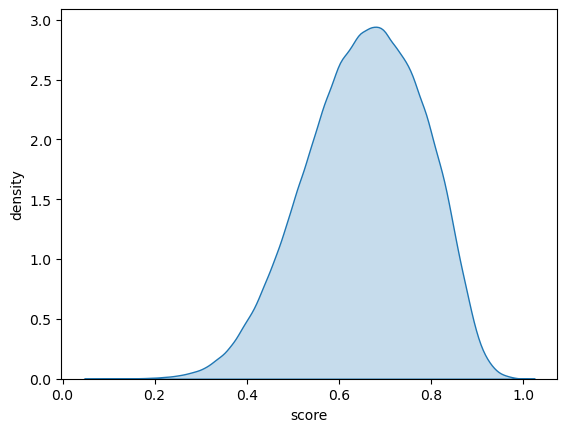

In [ ]:
mean = all_scores.mean()
std = all_scores.std()
print(f"mean: {mean:.4f}, std: {std:.4f}")

fig, ax = plt.subplots()
sns.kdeplot(data=all_scores, fill=True)
ax.set_xlabel("score")
ax.set_ylabel("density")

#fig.savefig("Negation/data/figure1.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [104]:
print(f"upper bound = {math.acos(mean+2*std)/math.pi * 180}")
print(f"lower bound = {math.acos(mean-2*std)/math.pi * 180}")

upper bound = 24.773630538096942
lower bound = 66.22820948579569


In [131]:
all_conditional_scores = {}
all_scores = []

for cat, img_embed in all_imgs_embed.items():
    scores = all_cats_embed[[cat]] @ img_embed.t()
    all_conditional_scores[cat] = {}
    all_conditional_scores[cat]['scores'] = scores.squeeze(dim=0).numpy()
    all_conditional_scores[cat]['mean'] = np.mean(all_conditional_scores[cat]['scores']).item()
    all_conditional_scores[cat]['std'] = np.std(all_conditional_scores[cat]['scores']).item()
    all_scores.append(all_conditional_scores[cat]['scores'])
    

all_scores = np.concatenate(all_scores, axis=0)

In [132]:
for cat, stats in all_conditional_scores.items():
    print(f"{dataset.cat_names[cat]}: ", f"{stats['mean']:.4f}, {stats['std']:.4f}")

ray:  0.2407, 0.0475
pear:  0.2633, 0.0414
lamp:  0.2608, 0.0242
spider:  0.2842, 0.0220
raccoon:  0.2843, 0.0361
shark:  0.2732, 0.0259
chimpanzee:  0.2740, 0.0333
telephone:  0.2561, 0.0333
pickup truck:  0.2560, 0.0189
rocket:  0.2592, 0.0329
streetcar:  0.2790, 0.0390
seal:  0.2776, 0.0368
cockroach:  0.2892, 0.0377
lizard:  0.2791, 0.0315
mountain:  0.2469, 0.0305
oak tree:  0.2643, 0.0339
lawn mower:  0.2964, 0.0197
worm:  0.2673, 0.0378
bowl:  0.2711, 0.0343
flatfish:  0.2969, 0.0346
aquarium fish:  0.2815, 0.0267
porcupine:  0.3025, 0.0407
possum:  0.3024, 0.0257
bus:  0.2507, 0.0288
willow tree:  0.2836, 0.0443
woman:  0.2213, 0.0242
man:  0.2149, 0.0242
house:  0.2416, 0.0241
maple tree:  0.2728, 0.0264
clock:  0.2720, 0.0259
dolphin:  0.2696, 0.0333
keyboard:  0.2679, 0.0315
cup:  0.2429, 0.0319
crocodile:  0.2894, 0.0344
bed:  0.2760, 0.0171
girl:  0.2268, 0.0262
chair:  0.2678, 0.0235
turtle:  0.2708, 0.0347
squirrel:  0.2743, 0.0359
pine tree:  0.2599, 0.0325
snake:  0.28

mean: 0.2689, std: 0.0360


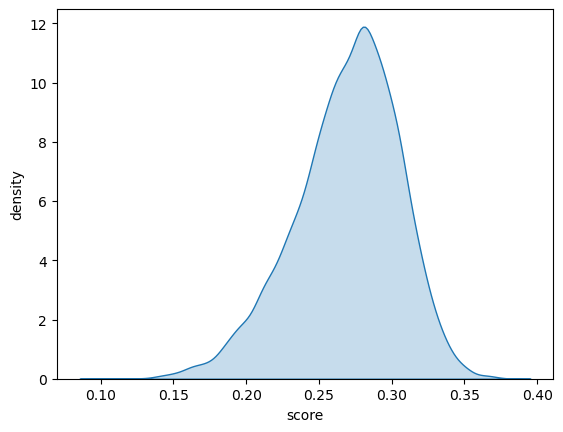

In [133]:
mean = all_scores.mean()
std = all_scores.std()
print(f"mean: {mean:.4f}, std: {std:.4f}")

fig, ax = plt.subplots()
sns.kdeplot(data=all_scores, fill=True)
ax.set_xlabel("score")
ax.set_ylabel("density")

fig.savefig("Negation/data/figure2.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [ ]:
print(f"upper bound = {math.acos(mean+3*std)/math.pi * 180}")
print(f"lower bound = {math.acos(mean-3*std)/math.pi * 180}")

upper bound = 67.85990264911271
lower bound = 80.73492577978924
